In [1]:
from google.colab import drive

In [2]:
drive.mount('/content/drive')
data_dir = '/content/drive/MyDrive/AI Assignment 5th Sem/ML_ready.csv'

Mounted at /content/drive


**Importing Required Libraries**

In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
data = pd.read_csv(data_dir)

Displaying meta-data

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19761 entries, 0 to 19760
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PC1             19761 non-null  float64
 1   PC2             19761 non-null  float64
 2   PC3             19761 non-null  float64
 3   label           19761 non-null  int64  
 4   ra              19761 non-null  float64
 5   dec             19761 non-null  float64
 6   j_mag           19761 non-null  float64
 7   h_mag           19761 non-null  float64
 8   k_mag           19761 non-null  float64
 9   kep_mag         19761 non-null  float64
 10  planet_radius   19761 non-null  float64
 11  orbital_period  19761 non-null  float64
 12  star_teff       19761 non-null  float64
 13  star_logg       19761 non-null  float64
 14  star_radius     19761 non-null  float64
 15  star_mass       19761 non-null  float64
 16  lc_time0        19761 non-null  float64
dtypes: float64(16), int64(1)
memory

**Exploratory Data Analysis**

Class distibution plot

/tmp/ipython-input-934774232.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=data, palette='viridis')


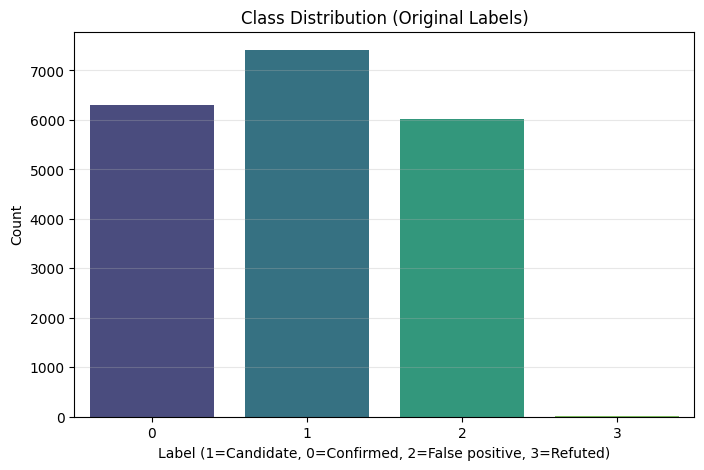

In [6]:
# Visualization: Class Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=data, palette='viridis')
plt.title('Class Distribution (Original Labels)')
plt.xlabel('Label (1=Candidate, 0=Confirmed, 2=False positive, 3=Refuted)')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

Feature Distributions plot

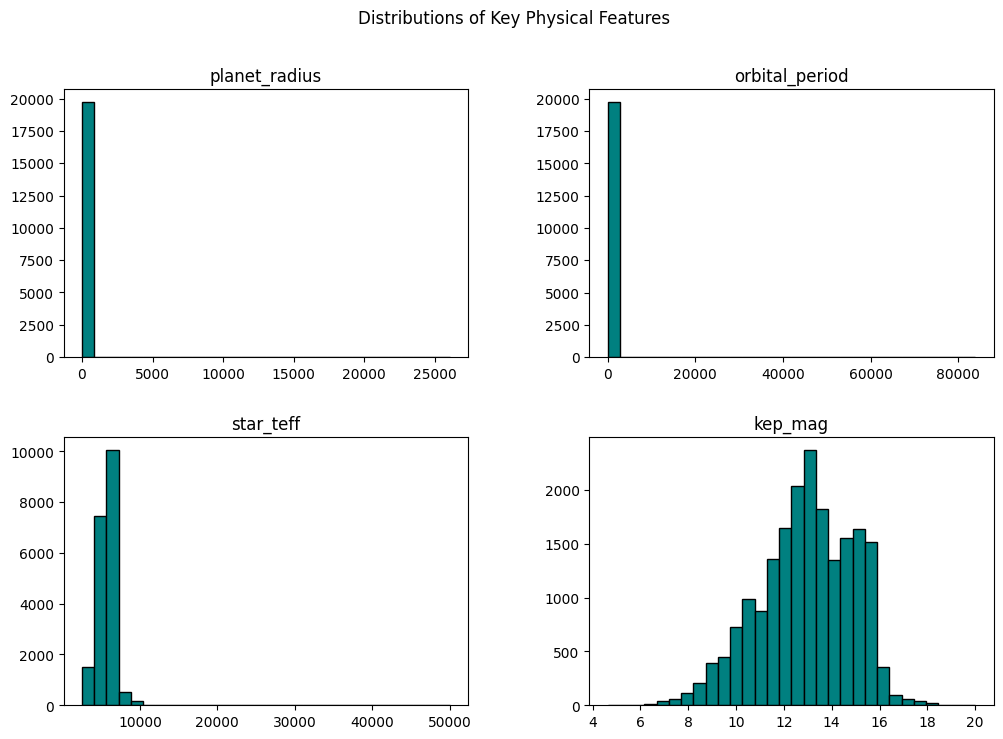

In [7]:
# Plot histograms for physical features to check for skewness
features_to_plot = ['planet_radius', 'orbital_period', 'star_teff', 'kep_mag']

data[features_to_plot].hist(bins=30, figsize=(12, 8), color='teal', edgecolor='black', grid=False)
plt.suptitle('Distributions of Key Physical Features')
plt.show()

Feature Correlation Analysis

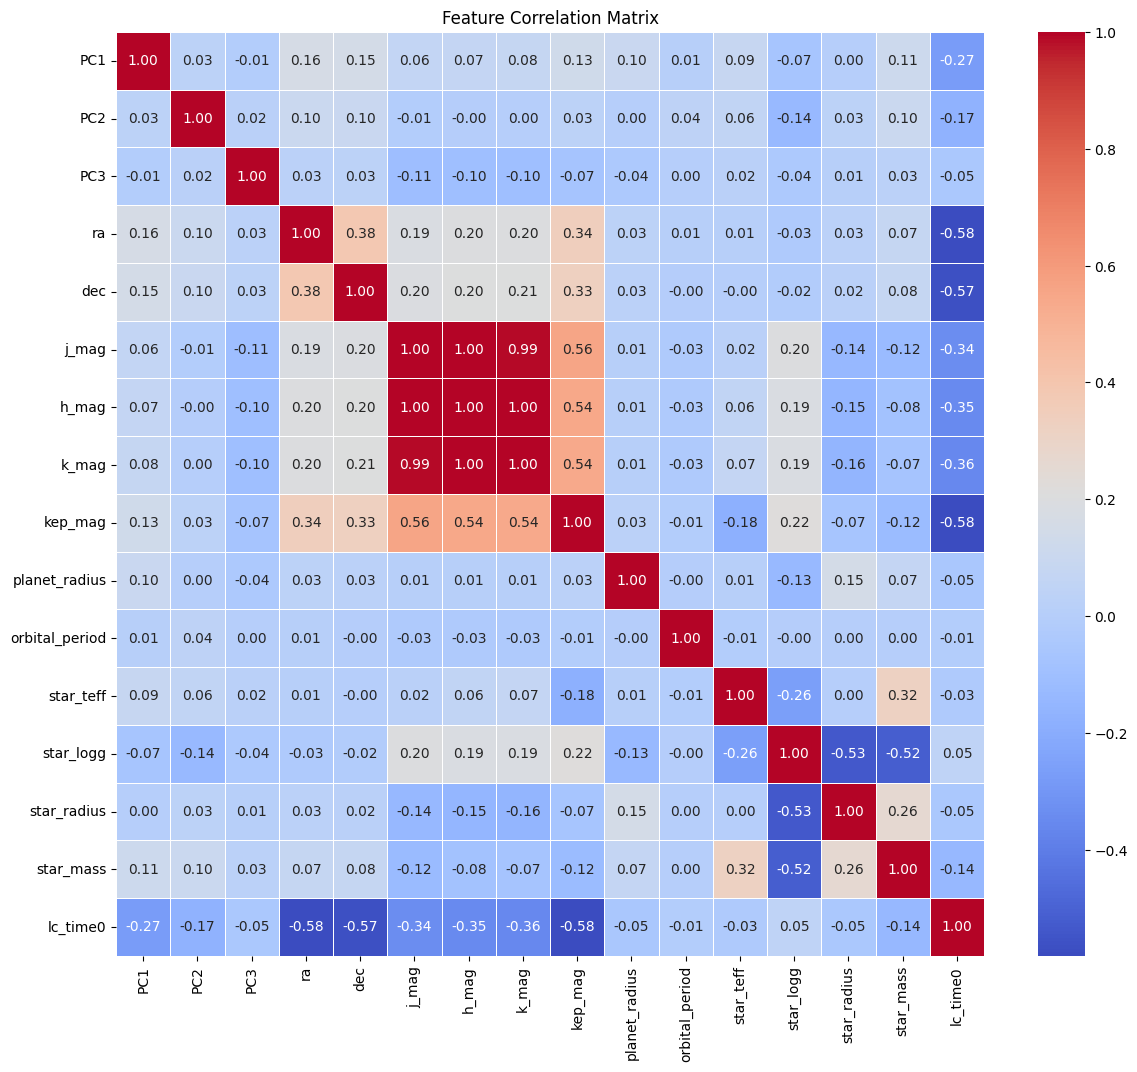

In [8]:
plt.figure(figsize=(14, 12))
correlation_matrix = data.drop(columns=['label']).corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

Identifying Target and feature variables

In [9]:
X = data.drop(columns=["label"]).values
y = data["label"].values

Splitting the dataset into train and validation set

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Scaling the features

In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Converting to PyTorch tensors

In [12]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test,  dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64)

Defining attention mechanism

In [13]:
class FeatureAttention(nn.Module):
    def __init__(self, input_dim, reduction=8):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(input_dim, input_dim // reduction),
            nn.ReLU(),
            nn.Linear(input_dim // reduction, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        weights = self.attention(x)
        return x * weights

In [14]:
class AttentionResidualMLP(nn.Module):
    def __init__(self, input_dim, num_classes=4):
        super().__init__()

        self.attn1 = FeatureAttention(input_dim)
        self.fc1 = nn.Linear(input_dim, 512)

        self.attn2 = FeatureAttention(512)
        self.fc2 = nn.Linear(512, 256)

        self.fc3 = nn.Linear(256, 128)
        self.out = nn.Linear(128, num_classes)

        self.relu = nn.ReLU()
        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.bn3 = nn.BatchNorm1d(128)

        self.drop = nn.Dropout(0.3)

    def forward(self, x):
        # Stage 1
        x = self.attn1(x)
        h1 = self.relu(self.bn1(self.fc1(x)))
        h1 = self.drop(h1)

        # Stage 2 (residual-style)
        h2 = self.attn2(h1)
        h2 = self.relu(self.bn2(self.fc2(h2)))
        h2 = self.drop(h2)

        # Stage 3
        h3 = self.relu(self.bn3(self.fc3(h2)))

        return self.out(h3)

Initializing the model

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionResidualMLP(
    input_dim=X_train.shape[1],
    num_classes=4
).to(device)

In [16]:
# Class weights
class_counts = np.bincount(y_train.numpy())
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [17]:
EPOCHS = 275

train_acc_history = []
val_acc_history = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_acc = correct / total

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = torch.argmax(model(xb), dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)

    val_acc = val_correct / val_total
        # 🔹 STORE ACCURACIES
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/275] | Loss: 250.5424 | Train Acc: 0.5908 | Val Acc: 0.5970
Epoch [2/275] | Loss: 236.7322 | Train Acc: 0.6098 | Val Acc: 0.5871
Epoch [3/275] | Loss: 221.9986 | Train Acc: 0.6234 | Val Acc: 0.5869
Epoch [4/275] | Loss: 218.7243 | Train Acc: 0.6270 | Val Acc: 0.6003
Epoch [5/275] | Loss: 215.4800 | Train Acc: 0.6310 | Val Acc: 0.5452
Epoch [6/275] | Loss: 207.7192 | Train Acc: 0.6382 | Val Acc: 0.6453
Epoch [7/275] | Loss: 204.0244 | Train Acc: 0.6441 | Val Acc: 0.6441
Epoch [8/275] | Loss: 197.1002 | Train Acc: 0.6471 | Val Acc: 0.6451
Epoch [9/275] | Loss: 195.1510 | Train Acc: 0.6471 | Val Acc: 0.6575
Epoch [10/275] | Loss: 196.0469 | Train Acc: 0.6528 | Val Acc: 0.5788
Epoch [11/275] | Loss: 196.5270 | Train Acc: 0.6524 | Val Acc: 0.6592
Epoch [12/275] | Loss: 197.7129 | Train Acc: 0.6569 | Val Acc: 0.6610
Epoch [13/275] | Loss: 195.8429 | Train Acc: 0.6590 | Val Acc: 0.6565
Epoch [14/275] | Loss: 189.3924 | Train Acc: 0.6635 | Val Acc: 0.6598
Epoch [15/275] | Loss: 186.91

Training the model

In [18]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.numpy())

In [19]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=[
        "CONFIRMED",
        "CANDIDATE",
        "FALSE POSITIVE",
        "REFUTED"
    ]
))

                precision    recall  f1-score   support

     CONFIRMED       0.69      0.82      0.75      1263
     CANDIDATE       0.70      0.66      0.68      1483
FALSE POSITIVE       0.79      0.67      0.73      1203
       REFUTED       0.07      0.50      0.12         4

      accuracy                           0.72      3953
     macro avg       0.56      0.66      0.57      3953
  weighted avg       0.73      0.72      0.72      3953



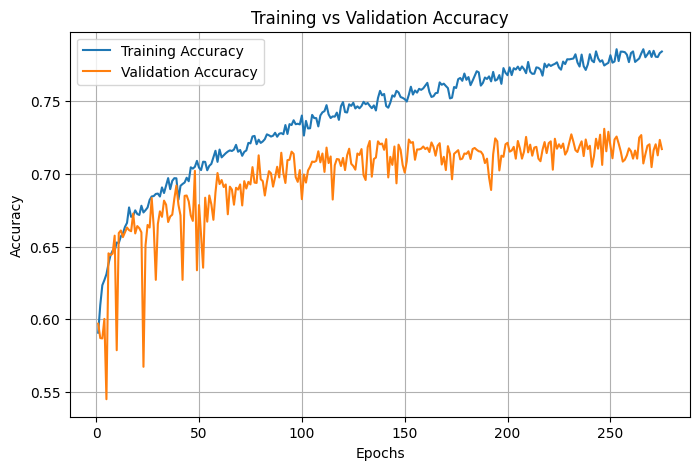

In [20]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc_history, label="Training Accuracy")
plt.plot(epochs, val_acc_history, label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()